In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

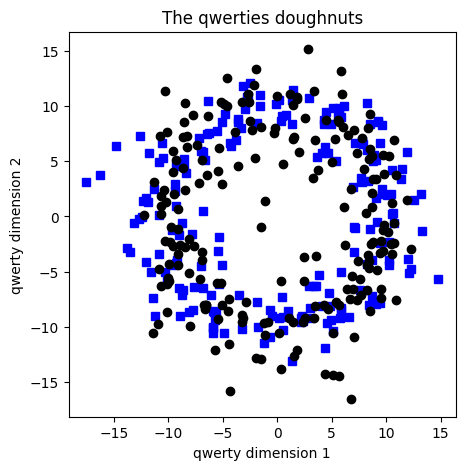

In [9]:
nPerClust = 200

th = np.linspace(0,4*np.pi,nPerClust)
r1 = 10
r2 = 15

a = [r1*np.cos(th) + np.random.randn(nPerClust)*3, 
     r1*np.sin(th) + np.random.randn(nPerClust)]

b = [r1*np.sin(th) + np.random.randn(nPerClust), 
     r1*np.cos(th) + np.random.randn(nPerClust)*3]

labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

data_np = np.hstack((a,b)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties doughnuts')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [10]:
train_data, test_data, train_labels, test_labels = train_test_split(data_np, labels_np, train_size=0.8)

train_tensor = TensorDataset(torch.tensor(train_data).float(), torch.tensor(train_labels).float())
test_tensor = TensorDataset(torch.tensor(test_data).float(), torch.tensor(test_labels).float())

batch_size = 16
train_dataloader = DataLoader(train_tensor, batch_size=16, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_tensor, batch_size=16)

In [11]:
class DLModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Dropout regularization
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Dropout(p=0.1),

            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.1),

            nn.Linear(64,1)
        )

    def forward(self, X):
        return self.net(X)

In [12]:
model = DLModel()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4) # L2 regularization

lossfun = nn.BCEWithLogitsLoss()

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DLModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [14]:
trainAcc = []
testAcc = []
losses = []

# ===== Epochs =====
numepochs = 10000
for epochi in range(numepochs):

    # ===== Training =====
    model.train()
    epoch_loss = 0
    batchAcc = []

    for X, y in train_dataloader:
        X = X.to(device)
        y = y.to(device)
        
        # Forward
        yHat = model(X)
        loss = lossfun(yHat, y)
        batchAcc = []

        epoch_loss += loss.item()
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accuracy
        pred_labels = (yHat > 0).float()
        acc = (pred_labels == y).float().mean()
        batchAcc.append(acc.item())

    trainAcc.append(sum(batchAcc)/len(batchAcc)*100)
    losses.append(epoch_loss/len(train_dataloader))

    # ===== Testing =====
    model.eval()
    batchError = []

    with torch.no_grad():
        for X, y in test_dataloader:
            X = X.to(device)
            y = y.to(device)
            
            yHat = model(X)

            # Accuracy
            pred_labels = (yHat > 0).float()
            acc = (pred_labels == y).float().mean()
            batchAcc.append(acc.item())

    testAcc.append((sum(batchAcc)/len(batchAcc))*100)

    # Imprimir progreso cada 100 épocas
    if (epochi + 1) % 100 == 0:
        print(f"Epoch {epochi+1:04d} | Train Acc: {trainAcc[-1]:.2f}% | Test Acc: {testAcc[-1]:.2f}% |")

Epoch 0100 | Train Acc: 43.75% | Test Acc: 45.83% | Mean Accuracy: 48.35%
Epoch 0200 | Train Acc: 50.00% | Test Acc: 46.88% | Mean Accuracy: 49.03%
Epoch 0300 | Train Acc: 37.50% | Test Acc: 43.75% | Mean Accuracy: 49.62%
Epoch 0400 | Train Acc: 62.50% | Test Acc: 48.96% | Mean Accuracy: 49.31%
Epoch 0500 | Train Acc: 43.75% | Test Acc: 44.79% | Mean Accuracy: 48.99%
Epoch 0600 | Train Acc: 81.25% | Test Acc: 51.04% | Mean Accuracy: 49.09%
Epoch 0700 | Train Acc: 50.00% | Test Acc: 46.88% | Mean Accuracy: 48.98%
Epoch 0800 | Train Acc: 43.75% | Test Acc: 44.79% | Mean Accuracy: 49.08%
Epoch 0900 | Train Acc: 50.00% | Test Acc: 45.83% | Mean Accuracy: 49.05%
Epoch 1000 | Train Acc: 56.25% | Test Acc: 46.88% | Mean Accuracy: 49.15%
Epoch 1100 | Train Acc: 31.25% | Test Acc: 42.71% | Mean Accuracy: 49.03%
Epoch 1200 | Train Acc: 56.25% | Test Acc: 46.88% | Mean Accuracy: 48.98%
Epoch 1300 | Train Acc: 62.50% | Test Acc: 47.92% | Mean Accuracy: 48.91%
Epoch 1400 | Train Acc: 68.75% | Test 